# Contrastive Dependency Tree Pairs Dataset (n=5-8)

This notebook demonstrates the generation and analysis of a synthetic dataset of projective linearizations across rooted dependency trees. For each linearization, it computes:

- **Dependency Distance (DD) multiset** and total DD
- **Instantaneous Memory Burden (IMB)** profile at each word position
- **Load Leveling Factor (LLF)** = mean_imb / max_imb
- **Superlinear processing costs** at α = 1.0, 1.2, 1.5, 2.0, 3.0

**Key finding**: Contrastive groups exist where linearizations share identical DD multisets but differ in max(IMB) and LLF, proving that temporal dependency overlap is a novel signal invisible to aggregate DD statistics.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import itertools
import json
import math
import os
import sys
import time
from collections import defaultdict

from loguru import logger
import matplotlib.pyplot as plt

# Configure logging for notebook
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-e4150b-head-directionality-dependent-temporal-d/main/dataset_iter1_contrastive_dep/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
examples = data["datasets"][0]["examples"]
print(f"Loaded {len(examples)} examples")

Loaded 16 examples


In [5]:
# =========================================================================
# Configuration — tune these parameters
# =========================================================================
MAX_N = 8           # Maximum tree size to enumerate (original: 8)
ALPHAS = [1.0, 1.2, 1.5, 2.0, 3.0]  # Superlinear cost exponents
OEIS_A000081 = {1: 1, 2: 1, 3: 2, 4: 4, 5: 9, 6: 20, 7: 48, 8: 115}

# Worked-example heads arrays
WORKED_A_HEADS = [0, 1, 2, 2, 3]
WORKED_B_HEADS = [0, 1, 1, 3, 3]

## Explore Pre-Generated Data

Examine the structure and content of the loaded dataset examples. Each example contains an input (tree topology, heads array) and output (DD multiset, IMB profile, LLF, costs).

In [6]:
# Parse and display a few examples from the loaded data
for i, ex in enumerate(examples[:4]):
    inp = json.loads(ex["input"])
    out = json.loads(ex["output"])
    print(f"\n--- Example {i} ---")
    print(f"  n_words: {inp['n_words']}, topology: {inp['tree_topology']}")
    print(f"  heads_array: {inp['heads_array']}")
    print(f"  DD multiset: {out['dd_multiset']}")
    print(f"  IMB profile: {out['imb_profile']}")
    print(f"  LLF: {out['llf']:.4f}, max_imb: {out['max_imb']}")
    print(f"  Contrastive: {ex['metadata_is_contrastive']}, "
          f"Cross-topo: {ex['metadata_is_cross_contrastive']}")
    print(f"  Worked example: {ex['metadata_is_worked_example']}")


--- Example 0 ---
  n_words: 5, topology: (()(()()))
  heads_array: [0, 1, 1, 3, 3]
  DD multiset: 1,1,2,2
  IMB profile: [0.0, 2.0, 2.0, 2.0, 2.0]
  LLF: 0.8000, max_imb: 2.0
  Contrastive: True, Cross-topo: True
  Worked example: True

--- Example 1 ---
  n_words: 5, topology: nonprojective_worked_example_A
  heads_array: [0, 1, 2, 2, 3]
  DD multiset: 1,1,2,2
  IMB profile: [0.0, 1.0, 2.0, 3.0, 2.0]
  LLF: 0.5333, max_imb: 3.0
  Contrastive: False, Cross-topo: True
  Worked example: True

--- Example 2 ---
  n_words: 5, topology: (()()()())
  heads_array: [0, 1, 1, 1, 1]
  DD multiset: 1,2,3,4
  IMB profile: [0.0, 4.0, 6.0, 6.0, 4.0]
  LLF: 0.6667, max_imb: 6.0
  Contrastive: True, Cross-topo: True
  Worked example: False

--- Example 3 ---
  n_words: 5, topology: (()()()())
  heads_array: [5, 5, 5, 5, 0]
  DD multiset: 1,2,3,4
  IMB profile: [0.0, 1.0, 3.0, 6.0, 10.0]
  LLF: 0.4000, max_imb: 10.0
  Contrastive: True, Cross-topo: True
  Worked example: False


## 1. Tree Enumeration (OEIS A000081)

Enumerate all non-isomorphic rooted trees on  nodes using integer partitions. Each tree is represented as a canonical nested tuple. The counts must match [OEIS A000081](https://oeis.org/A000081).

In [7]:
_tree_cache: dict[int, list[tuple]] = {}


def _partitions(n: int, min_part: int = 1):
    """Yield integer partitions of n with parts in non-decreasing order."""
    if n == 0:
        yield ()
        return
    for first in range(min_part, n + 1):
        for rest in _partitions(n - first, first):
            yield (first,) + rest


def enum_rooted_trees(n: int) -> list[tuple]:
    """All non-isomorphic rooted trees on n nodes as canonical nested tuples."""
    if n in _tree_cache:
        return _tree_cache[n]
    if n == 1:
        _tree_cache[1] = [()]
        return [()]

    results: set[tuple] = set()
    for partition in _partitions(n - 1):
        # Group consecutive equal parts
        groups: list[tuple[int, int]] = []
        i = 0
        while i < len(partition):
            sz = partition[i]
            cnt = 0
            while i < len(partition) and partition[i] == sz:
                cnt += 1
                i += 1
            groups.append((sz, cnt))

        group_opts = []
        for sz, cnt in groups:
            trees = enum_rooted_trees(sz)
            group_opts.append(
                list(itertools.combinations_with_replacement(trees, cnt))
            )

        for combo in itertools.product(*group_opts):
            children: list[tuple] = []
            for grp in combo:
                children.extend(grp)
            results.add(tuple(sorted(children)))

    result_list = sorted(results)
    _tree_cache[n] = result_list
    return result_list


def tree_to_str(t: tuple) -> str:
    """Canonical string like '(()())'."""
    if not t:
        return "()"
    return "(" + "".join(tree_to_str(c) for c in t) + ")"


def count_proj_lins(t: tuple) -> int:
    """Count projective linearizations without enumerating."""
    if not t:
        return 1
    k = len(t)
    return math.factorial(k + 1) * math.prod(count_proj_lins(c) for c in t)

## 2. Labeling & Projective Linearization

Assign DFS labels to tree nodes, then enumerate all projective (crossing-free) linearizations where the head can appear in any position among its dependents.

In [8]:
def assign_labels(tree: tuple, start: int = 0):
    """DFS-label tree nodes. Returns ((label, [children]), next_label)."""
    label = start
    nxt = start + 1
    children = []
    for sub in tree:
        child, nxt = assign_labels(sub, nxt)
        children.append(child)
    return (label, children), nxt


def get_parent_map(labeled_tree) -> dict[int, int]:
    """node_label -> parent_label  (root -> -1)."""
    parent: dict[int, int] = {}

    def _visit(node, par):
        lbl, ch = node
        parent[lbl] = par
        for c in ch:
            _visit(c, lbl)

    _visit(labeled_tree, -1)
    return parent


def projective_lins(labeled_tree):
    """Yield all projective linearizations as lists of node labels."""
    lbl, children = labeled_tree
    if not children:
        yield [lbl]
        return
    k = len(children)
    child_lins = [list(projective_lins(c)) for c in children]

    for perm in itertools.permutations(range(k)):
        for head_pos in range(k + 1):
            ordered = [child_lins[perm[i]] for i in range(k)]
            for combo in itertools.product(*ordered):
                result: list[int] = []
                for i in range(head_pos):
                    result.extend(combo[i])
                result.append(lbl)
                for i in range(head_pos, k):
                    result.extend(combo[i])
                yield result

## 3. Metric Computation

For each linearization (given as a ), compute:
- **DD list**: dependency distances for each arc
- **IMB profile**: instantaneous memory burden at each position
- **LLF**: Load Leveling Factor = mean(IMB) / max(IMB)
- **Superlinear costs**: sum of IMB^α for each α

Also verifies the mathematical identity: .

In [9]:
def compute_metrics_from_heads(heads_array: list[int]) -> dict:
    """Compute all metrics directly from a 1-indexed heads_array (0=root)."""
    n = len(heads_array)
    dd_list: list[int] = []
    deps: list[tuple[int, int]] = []
    for j in range(n):
        h = heads_array[j]
        if h != 0:
            dep_pos = j + 1
            dd = abs(dep_pos - h)
            dd_list.append(dd)
            deps.append((min(dep_pos, h), max(dep_pos, h)))

    dd_sorted = sorted(dd_list)
    dd_multiset = ",".join(str(d) for d in dd_sorted)

    # IMB profile
    imb = [0.0] * n
    for j_pos in range(1, n + 1):
        burden = 0.0
        for op, cl in deps:
            if op <= j_pos <= cl:
                burden += (j_pos - op)
        imb[j_pos - 1] = burden

    max_imb = max(imb) if imb else 0.0
    total_imb = sum(imb)
    mean_imb = total_imb / n if n > 0 else 0.0
    llf = mean_imb / max_imb if max_imb > 0 else 0.0

    total_imb_formula = sum(d * (d + 1) / 2.0 for d in dd_list)
    formula_verified = abs(total_imb - total_imb_formula) < 1e-9

    costs = {a: sum(v ** a for v in imb) for a in ALPHAS}

    return {
        "dd_list": dd_sorted,
        "dd_multiset": dd_multiset,
        "imb_profile": imb,
        "max_imb": max_imb,
        "mean_imb": mean_imb,
        "llf": llf,
        "total_imb": total_imb,
        "total_imb_formula": total_imb_formula,
        "formula_verified": formula_verified,
        "cost_alpha_1_0": costs[1.0],
        "cost_alpha_1_2": costs[1.2],
        "cost_alpha_1_5": costs[1.5],
        "cost_alpha_2_0": costs[2.0],
        "cost_alpha_3_0": costs[3.0],
    }


def lin_to_heads(linearization: list[int], parent_map: dict[int, int]) -> list[int]:
    """Convert a linearization + parent_map to a 1-indexed heads_array."""
    pos_of = {label: i + 1 for i, label in enumerate(linearization)}
    heads: list[int] = []
    for label in linearization:
        par = parent_map[label]
        heads.append(0 if par == -1 else pos_of[par])
    return heads

## 4. Process Tree Shapes

For each tree shape, enumerate all unique projective linearizations and compute metrics for each one.

In [10]:
def process_tree_shape(n: int, shape_idx: int, tree_shape: tuple) -> list[dict]:
    """Enumerate unique projective linearizations for one shape, compute metrics."""
    tree_id = f"t{n}_{shape_idx:03d}"
    tree_str = tree_to_str(tree_shape)

    labeled_tree, _ = assign_labels(tree_shape)
    parent_map = get_parent_map(labeled_tree)

    seen_heads: set[tuple[int, ...]] = set()
    rows: list[dict] = []
    lin_id = 0

    for lin in projective_lins(labeled_tree):
        ha = lin_to_heads(lin, parent_map)
        ha_key = tuple(ha)
        if ha_key in seen_heads:
            continue
        seen_heads.add(ha_key)

        metrics = compute_metrics_from_heads(ha)
        rows.append({
            "n_words": n,
            "tree_topology": tree_str,
            "tree_topology_id": tree_id,
            "linearization_id": lin_id,
            "heads_array": ha,
            **metrics,
        })
        lin_id += 1

    return rows

## 5. Worked Example Validation

Validate the key theoretical claim using the worked example from the hypothesis:
- **Tree A** (heads=[0,1,2,2,3]): IMB=[0,1,2,3,2], LLF=0.533, cost@α=2 → 18
- **Tree B** (heads=[0,1,1,3,3]): IMB=[0,2,2,2,2], LLF=0.800, cost@α=2 → 16

Both share DD multiset {1,1,2,2} but differ in superlinear costs — proving LLF captures information invisible to DD.

In [11]:
# Compute metrics for the worked example
ma = compute_metrics_from_heads(WORKED_A_HEADS)
mb = compute_metrics_from_heads(WORKED_B_HEADS)

expected_a = {"imb": [0, 1, 2, 3, 2], "llf": 8 / 15, "cost2": 18.0}
expected_b = {"imb": [0, 2, 2, 2, 2], "llf": 0.8, "cost2": 16.0}

ok_a = (
    ma["imb_profile"] == expected_a["imb"]
    and abs(ma["llf"] - expected_a["llf"]) < 1e-4
    and ma["cost_alpha_2_0"] == expected_a["cost2"]
)
ok_b = (
    mb["imb_profile"] == expected_b["imb"]
    and abs(mb["llf"] - expected_b["llf"]) < 1e-4
    and mb["cost_alpha_2_0"] == expected_b["cost2"]
)

logger.info(f"Worked-example Tree A: IMB={ma['imb_profile']} LLF={ma['llf']:.4f} "
            f"cost_a2={ma['cost_alpha_2_0']}  PASS={ok_a}")
logger.info(f"Worked-example Tree B: IMB={mb['imb_profile']} LLF={mb['llf']:.4f} "
            f"cost_a2={mb['cost_alpha_2_0']}  PASS={ok_b}")
logger.info(f"Same DD multiset: {ma['dd_multiset']}=={mb['dd_multiset']} "
            f"→ {ma['dd_multiset'] == mb['dd_multiset']}")
logger.info(f"Same cost@1.0: {ma['cost_alpha_1_0']}=={mb['cost_alpha_1_0']} "
            f"→ {abs(ma['cost_alpha_1_0'] - mb['cost_alpha_1_0']) < 1e-9}")

01:18:21|INFO   |Worked-example Tree A: IMB=[0.0, 1.0, 2.0, 3.0, 2.0] LLF=0.5333 cost_a2=18.0  PASS=True


01:18:21|INFO   |Worked-example Tree B: IMB=[0.0, 2.0, 2.0, 2.0, 2.0] LLF=0.8000 cost_a2=16.0  PASS=True


01:18:21|INFO   |Same DD multiset: 1,1,2,2==1,1,2,2 → True


01:18:21|INFO   |Same cost@1.0: 8.0==8.0 → True


## 6. Main Pipeline: Enumerate and Process Trees

Run the full pipeline for tree sizes n=5 to MAX_N. This enumerates all tree shapes, generates projective linearizations, computes metrics, and identifies contrastive groups.

In [12]:
logger.info("=== Contrastive Dependency Tree Pairs Dataset ===")
logger.info(f"MAX_N={MAX_N}")

# ---- Phase 1: enumerate shapes, predict scale ------------------
logger.info("Phase 1: Enumerating tree shapes and predicting scale...")
all_shapes: dict[int, list[tuple]] = {}
for n in range(5, MAX_N + 1):
    shapes = enum_rooted_trees(n)
    expected = OEIS_A000081[n]
    if len(shapes) != expected:
        logger.error(f"n={n}: {len(shapes)} shapes vs expected {expected}")
        raise ValueError(f"Tree enumeration bug at n={n}")
    total_lins = sum(count_proj_lins(s) for s in shapes)
    all_shapes[n] = shapes
    logger.info(f"  n={n}: {len(shapes)} shapes, "
                f"{total_lins:,} raw projective linearizations")

# ---- Phase 2: process shapes -----------------------------------
logger.info("Phase 2: Computing metrics for all unique linearizations...")
all_rows: list[dict] = []

for n in sorted(all_shapes):
    shapes = all_shapes[n]
    t0 = time.time()
    before = len(all_rows)

    for idx, shape in enumerate(shapes):
        all_rows.extend(process_tree_shape(n, idx, shape))

    added = len(all_rows) - before
    elapsed = time.time() - t0
    logger.info(f"  n={n}: {added:,} unique heads_arrays in {elapsed:.1f}s")

logger.info(f"Total unique linearizations: {len(all_rows):,}")

# ---- Formula verification --------------------------------------
n_ok = sum(1 for r in all_rows if r["formula_verified"])
n_fail = len(all_rows) - n_ok
logger.info(f"Formula verified: {n_ok:,} OK, {n_fail:,} FAIL  "
            f"({100 * n_ok / max(len(all_rows), 1):.2f}%)")

01:18:21|INFO   |=== Contrastive Dependency Tree Pairs Dataset ===


01:18:21|INFO   |MAX_N=8


01:18:21|INFO   |Phase 1: Enumerating tree shapes and predicting scale...


01:18:21|INFO   |  n=5: 9 shapes, 364 raw projective linearizations


01:18:21|INFO   |  n=6: 20 shapes, 2,480 raw projective linearizations


...

01:18:21|INFO   |  n=6: 728 unique heads_arrays in 0.0s


01:18:22|INFO   |  n=7: 3,876 unique heads_arrays in 0.1s


01:18:22|INFO   |  n=8: 21,318 unique heads_arrays in 0.5s


01:18:22|INFO   |Total unique linearizations: 26,065


01:18:22|INFO   |Formula verified: 26,065 OK, 0 FAIL  (100.00%)


## 7. Contrastive Group Analysis

Identify contrastive groups: sets of linearizations that share identical DD multisets but differ in max(IMB) and LLF. This is the core evidence that LLF provides novel information beyond DD.

In [13]:
# ---- Phase 3: contrastive groups --------------------------------
logger.info("Phase 3: Identifying contrastive groups...")

# Within-topology: (topology_id, dd_multiset)
within_grp: dict[tuple, list[int]] = defaultdict(list)
for i, r in enumerate(all_rows):
    within_grp[(r["tree_topology_id"], r["dd_multiset"])].append(i)

# Cross-topology: (n_words, dd_multiset)
cross_grp: dict[tuple, list[int]] = defaultdict(list)
for i, r in enumerate(all_rows):
    cross_grp[(r["n_words"], r["dd_multiset"])].append(i)

# Tag within-topology contrastive (different max_imb)
wg_id = 0
within_contrastive: dict[tuple, str] = {}
for key, idxs in within_grp.items():
    max_imbs = {all_rows[i]["max_imb"] for i in idxs}
    if len(max_imbs) > 1:
        within_contrastive[key] = f"wg_{wg_id:05d}"
        wg_id += 1

# Tag cross-topology contrastive (different max_imb across topologies)
xg_id = 0
cross_contrastive: dict[tuple, str] = {}
for key, idxs in cross_grp.items():
    max_imbs = {all_rows[i]["max_imb"] for i in idxs}
    if len(max_imbs) > 1:
        cross_contrastive[key] = f"xg_{xg_id:05d}"
        xg_id += 1

logger.info(f"  Within-topology contrastive groups: {len(within_contrastive):,}")
logger.info(f"  Cross-topology contrastive groups:  {len(cross_contrastive):,}")

# Annotate rows
for i, r in enumerate(all_rows):
    wk = (r["tree_topology_id"], r["dd_multiset"])
    xk = (r["n_words"], r["dd_multiset"])
    r["contrastive_group_id"] = within_contrastive.get(wk)
    r["cross_topo_group_id"] = cross_contrastive.get(xk)
    r["is_contrastive"] = wk in within_contrastive
    r["is_cross_contrastive"] = xk in cross_contrastive

# ---- Validation: cost@1.0 identity ----------------------------
logger.info("Phase 4: Validating contrastive properties...")
cost10_violations = 0
for key, gid in within_contrastive.items():
    idxs = within_grp[key]
    c10s = [all_rows[i]["cost_alpha_1_0"] for i in idxs]
    if max(c10s) - min(c10s) > 1e-9:
        cost10_violations += 1

logger.info(f"  cost@1.0 identity violations: {cost10_violations}")

# ---- Summary --------------------------------------------------
logger.info("=== SUMMARY ===")
for n in sorted(all_shapes):
    prefix = f"t{n}_"
    nr = sum(1 for r in all_rows if r["tree_topology_id"].startswith(prefix))
    nc = sum(1 for r in all_rows
             if r["tree_topology_id"].startswith(prefix) and r["is_contrastive"])
    nx = sum(1 for r in all_rows
             if r["tree_topology_id"].startswith(prefix) and r["is_cross_contrastive"])
    logger.info(f"  n={n}: {nr:,} rows, {nc:,} within-contrastive, "
                f"{nx:,} cross-contrastive")

n_contrastive = sum(1 for r in all_rows if r["is_contrastive"])
n_cross = sum(1 for r in all_rows if r["is_cross_contrastive"])
logger.info(f"  TOTAL: {len(all_rows):,} rows | "
            f"{n_contrastive:,} within-contrastive | "
            f"{n_cross:,} cross-contrastive")
logger.info(f"  Within-topo groups: {len(within_contrastive)} | "
            f"Cross-topo groups: {len(cross_contrastive)}")

01:18:22|INFO   |Phase 3: Identifying contrastive groups...


01:18:22|INFO   |  Within-topology contrastive groups: 5,179


01:18:22|INFO   |  Cross-topology contrastive groups:  164


01:18:22|INFO   |Phase 4: Validating contrastive properties...


01:18:22|INFO   |  cost@1.0 identity violations: 0


...

01:18:22|INFO   |  n=6: 728 rows, 628 within-contrastive, 722 cross-contrastive


01:18:22|INFO   |  n=7: 3,876 rows, 3,418 within-contrastive, 3,869 cross-contrastive


01:18:22|INFO   |  n=8: 21,318 rows, 19,762 within-contrastive, 21,310 cross-contrastive


01:18:22|INFO   |  TOTAL: 26,065 rows | 23,918 within-contrastive | 26,039 cross-contrastive


01:18:22|INFO   |  Within-topo groups: 5179 | Cross-topo groups: 164


## 8. Visualization

Plot the relationship between LLF and superlinear processing costs, and compare IMB profiles of the worked-example contrastive pair.

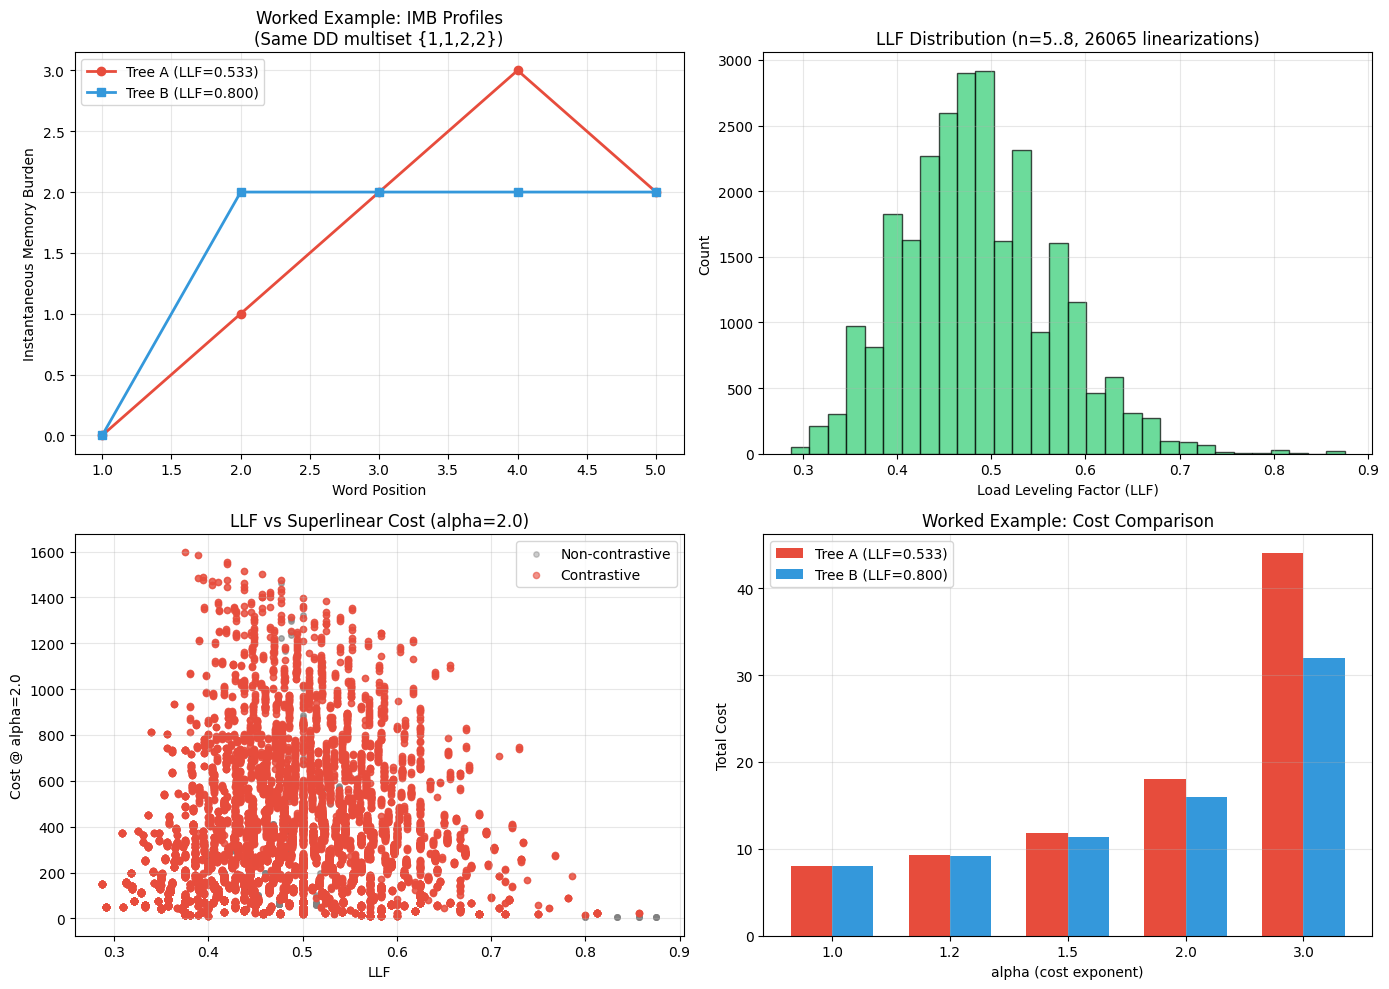


Key insight: Trees A and B share DD multiset {1,1,2,2} and identical cost@1.0,
but Tree B (higher LLF=0.800) has LOWER superlinear costs than Tree A (LLF=0.533).
This proves LLF captures temporal overlap information invisible to DD statistics.


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Plot 1: Worked example IMB profiles ---
ax = axes[0, 0]
positions = list(range(1, 6))
ax.plot(positions, ma["imb_profile"], 'o-', label=f'Tree A (LLF={ma["llf"]:.3f})', color='#e74c3c', linewidth=2)
ax.plot(positions, mb["imb_profile"], 's-', label=f'Tree B (LLF={mb["llf"]:.3f})', color='#3498db', linewidth=2)
ax.set_xlabel('Word Position')
ax.set_ylabel('Instantaneous Memory Burden')
ax.set_title('Worked Example: IMB Profiles\n(Same DD multiset {1,1,2,2})')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 2: LLF distribution across generated data ---
ax = axes[0, 1]
llf_values = [r["llf"] for r in all_rows]
ax.hist(llf_values, bins=30, edgecolor='black', alpha=0.7, color='#2ecc71')
ax.set_xlabel('Load Leveling Factor (LLF)')
ax.set_ylabel('Count')
ax.set_title(f'LLF Distribution (n=5..{MAX_N}, {len(all_rows)} linearizations)')
ax.grid(True, alpha=0.3)

# --- Plot 3: LLF vs cost@alpha=2.0 ---
ax = axes[1, 0]
contrastive_rows = [r for r in all_rows if r.get("is_contrastive")]
non_contrastive_rows = [r for r in all_rows if not r.get("is_contrastive")]
if non_contrastive_rows:
    ax.scatter([r["llf"] for r in non_contrastive_rows],
               [r["cost_alpha_2_0"] for r in non_contrastive_rows],
               alpha=0.4, s=15, color='gray', label='Non-contrastive')
if contrastive_rows:
    ax.scatter([r["llf"] for r in contrastive_rows],
               [r["cost_alpha_2_0"] for r in contrastive_rows],
               alpha=0.6, s=20, color='#e74c3c', label='Contrastive')
ax.set_xlabel('LLF')
ax.set_ylabel('Cost @ alpha=2.0')
ax.set_title('LLF vs Superlinear Cost (alpha=2.0)')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 4: Worked example cost comparison ---
ax = axes[1, 1]
alphas_plot = [1.0, 1.2, 1.5, 2.0, 3.0]
costs_a = [ma["cost_alpha_1_0"], ma["cost_alpha_1_2"], ma["cost_alpha_1_5"],
           ma["cost_alpha_2_0"], ma["cost_alpha_3_0"]]
costs_b = [mb["cost_alpha_1_0"], mb["cost_alpha_1_2"], mb["cost_alpha_1_5"],
           mb["cost_alpha_2_0"], mb["cost_alpha_3_0"]]
x = range(len(alphas_plot))
width = 0.35
ax.bar([i - width/2 for i in x], costs_a, width, label=f'Tree A (LLF={ma["llf"]:.3f})', color='#e74c3c')
ax.bar([i + width/2 for i in x], costs_b, width, label=f'Tree B (LLF={mb["llf"]:.3f})', color='#3498db')
ax.set_xlabel('alpha (cost exponent)')
ax.set_ylabel('Total Cost')
ax.set_title('Worked Example: Cost Comparison')
ax.set_xticks(list(x))
ax.set_xticklabels([str(a) for a in alphas_plot])
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results.png', dpi=100, bbox_inches='tight')
plt.show()
print("\nKey insight: Trees A and B share DD multiset {1,1,2,2} and identical cost@1.0,")
print("but Tree B (higher LLF=0.800) has LOWER superlinear costs than Tree A (LLF=0.533).")
print("This proves LLF captures temporal overlap information invisible to DD statistics.")